# <span style = "color:yellow">Encoding Categorical Data</span>

- Categorical data is of 2 types:
    - **Ordinal**: Categories have a natural order (e.g., "Low", "Medium", "High", grades like AA,AB,BB...).
    - **Nominal**: Categories do not have a natural order (e.g., "Red", "Green", "Blue").

    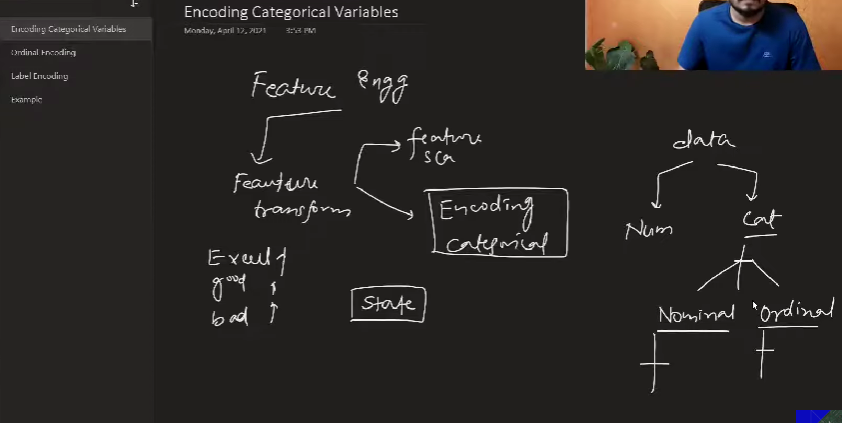

# How to encode categorical data?

- Generally, categorical datas are in form of strinngs. We need to convert them into numbers before feeding them to machine learning models.

- Ab numbe ko encode krne k bohot sare tarike hote hai, but hum 2 prakar ke encoding techniques dekhenge:
    - **Ordinal Encoding**: Ordinal data ko numbers me convert krna, jisme order ka dhyan rakha jata hai.
    - **One-Hot Encoding**: Nominal data ko binary vectors me convert krna, jisme har category ke liye ek column hota hai.

# <span style = "color:red">IMP</span>

- Agar X (Input features ko combined X kehte hai) me kisi col mei ordinal data hai, toh <span style = "color:blue">Ordinal Encoder</span> use kroge

- But agar target variable Y categorical hai(ex. Classification problems), toh <span style = "color:blue">Label Encoder</span> use kroge. (Label Encoder kaam exactly ordinal encoder ki tarah hi karta hai, but ye output labels k liye use hota hai, isliye iska naam label encoder hai)

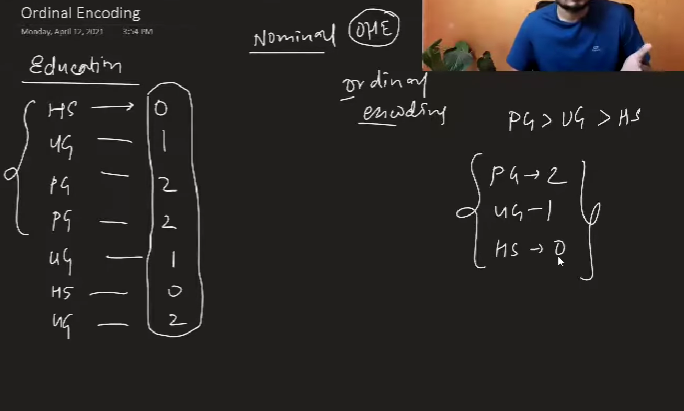

- Hume batana hota hai ki  PG->2, UG->1, HS->0 isliye ki PG ka order UG se bada hai, aur UG ka order HS se bada hai. Agar humne PG ko 0, UG ko 1, aur HS ko 2 encode kiya hota, toh model ko lagta ki PG ka order HS se chota hai, jo ki galat hai. Isliye hume ordinal data ko encode krte waqt uske order ka dhyan rakhna padta hai.

In [10]:
import numpy as np
import pandas as pd

In [28]:
df = pd.read_csv('customer.csv')

In [29]:
df.sample(5)

,age,gender,review,education,purchased
6,18,Male,Good,School,No
22,18,Female,Poor,PG,Yes
15,75,Male,Poor,UG,No
2,70,Female,Good,PG,No
12,51,Male,Poor,School,No


- Identify the categorical columns
    - gender: Nominal Categorical (One-Hot Encoder)
    - education: Ordinal Categorical (Ordinal Encoder)
    - review: Ordinal Categorical (Ordinal Encoder)
    - purchased: Nominal Categorical (Label Encoder)

- But abhi data set mei both nominal aur ordinal categorical features hai, so hume nominal/ordinal type k columns ko seperate krna padega and then transform krke jodna padega which is hechtic.
- Isse bachne k liye sklear ka ek class hai <span style = "color:blue">ColumnTransformer</span> jisme hum specify kr skte hai ki kaunse columns ko kaunsa transformer use krke transform krna hai, and then ye automatically un transformed columns ko jod dega. Isse hume alag alag columns ko transform krke manually jodne ki zarurat nahi padegi. (We will see this in detail in the next to next video)

In [30]:
# So for now we will only work with education and review columns, so we will drop the rest of the columns.
df = df.iloc[:,2:]

In [31]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


<span style = "color:yellow">So kvhi vhi jb aap feature transformation krte hai, then before applying any transformation, make sure to split the data into train and test sets. This is because you don't want to use information from the test set during training, as it would lead to data leakage and overfitting.</span>

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:2], df.iloc[:,-1], test_size = 0.2)

# df.iloc[:,0:2] means all rows and 0 and 1 columns, df.iloc[:,-1] means all rows and last column. So we are splitting the data into train and test sets, where X_train and y_train are the training data, and X_test and y_test are the testing data. We are using 20% of the data for testing and 80% for training.


In [33]:
X_test

,review,education
46,Poor,PG
30,Average,UG
10,Good,UG
13,Average,School
24,Average,PG
37,Average,PG
29,Average,UG
17,Poor,UG
0,Average,School
32,Average,UG


In [34]:
from sklearn.preprocessing import OrdinalEncoder

In [35]:
# make an ordinal encoder object, and specify the order of the categories in each column using the categories parameter.
# The categories parameter takes a list of lists, where each inner list contains the categories for a particular column in the order they should be encoded. 
# For example, if we have a column with three categories 'Poor', 'Average', and 'Good', and we want to encode them as 0, 1, and 2 respectively, we can specify the order as ['Poor', 'Average', 'Good'].
oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

In [36]:
oe.fit(X_train) # fit the ordinal encoder on the training data. This will learn the mapping of categories to integers based on the order we specified.

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Poor', 'Average', ...], ['School', 'UG', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [37]:
X_train = oe.transform(X_train) # transform the training data using the fitted ordinal encoder. This will replace the categories in the training data with their corresponding integer values based on the order we specified.
X_test = oe.transform(X_test) # transform the testing data using the fitted ordinal encoder. This will replace the categories in the testing data with their corresponding integer values based on the order we specified.

In [38]:
X_train

array([[0., 0.],
       [2., 1.],
       [2., 2.],
       [0., 1.],
       [0., 0.],
       [2., 1.],
       [2., 2.],
       [2., 1.],
       [2., 2.],
       [0., 2.],
       [2., 2.],
       [0., 2.],
       [1., 2.],
       [2., 0.],
       [0., 1.],
       [1., 1.],
       [2., 1.],
       [2., 0.],
       [0., 2.],
       [0., 2.],
       [0., 0.],
       [0., 2.],
       [2., 1.],
       [2., 2.],
       [0., 2.],
       [2., 0.],
       [0., 1.],
       [1., 0.],
       [0., 0.],
       [2., 0.],
       [0., 0.],
       [1., 1.],
       [0., 2.],
       [0., 2.],
       [2., 0.],
       [2., 2.],
       [1., 0.],
       [1., 1.],
       [1., 0.],
       [2., 0.]])

In [ ]:
# to see the categories and their corresponding integer values learned by the ordinal encoder, we can use the categories_ attribute of the fitted ordinal encoder object. This will return a list of arrays, where each array contains the categories for a particular column in the order they were encoded. 
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

In [41]:
X_test

array([[0., 2.],
       [1., 1.],
       [2., 1.],
       [1., 0.],
       [1., 2.],
       [1., 2.],
       [1., 1.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

In [42]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
# here we are using label encoder to encode the target variable, which is the last column in our dataset. Label encoder will assign a unique integer value to each category in the target variable.
# we no need to specify the order of the categories for label encoder, as it will automatically assign integer values based on the alphabetical order of the categories.

In [ ]:
le.fit(y_train) # fit based on the training data

LabelEncoder()

In [45]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [ ]:
# transform both the training and testing target variable using the fitted label encoder. This will replace the categories in the target variable with their corresponding integer values based on the alphabetical order of the categories.
y_train = le.transform(y_train) 
y_test = le.transform(y_test)

In [47]:
y_train

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0])